In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
rc('axes', fc='w')
rc('figure', fc='w')
rc('savefig', fc='w')
rc('axes', axisbelow=True)

In [2]:
from collections import deque

def all_shortest_from(G, s):
    """
    Unweighted BFS from source s.
    Returns:
      dist[v]  : shortest-path distance from s to v (=-1 if unreachable)
      g[v]     : number of shortest paths from s to v
      P[v]     : list of predecessors of v on shortest s->v paths
    """
    dist  = {v: -1 for v in G.nodes()}
    g = {v:  0 for v in G.nodes()}
    P = {v: [] for v in G.nodes()}

    dist[s] = 0
    g[s] = 1

    Q = deque([s])
    while Q:
        v = Q.popleft()
        for w in G.neighbors(v):
            if dist[w] < 0:
                dist[w] = dist[v] + 1
                Q.append(w)
            if dist[w] == dist[v] + 1:
                g[w] += g[v]
                P[w].append(v)
    return dist, g, P


def indicator_betweenness_unscaled(G, endpoints=False):
    """
    Indicator betweenness (UNWEIGHTED, UNSCALED):
      For each ordered pair (s, t), s!=t, every node i on at least one
      shortest s->t path gets + 1 / g_st (once per pair).

    endpoints=False: do NOT credit s or t.
    endpoints=True : DO credit s and t as well.
    """
    bc = {v: 0.0 for v in G.nodes()}
    nodes = list(G.nodes())

    for s in nodes:
        dist, g, P = all_shortest_from(G, s)

        # Consider only reachable targets t != s with g[t] > 0
        targets = [t for t in nodes if t != s and g[t] > 0]

        for t in targets:
            contrib = 1.0 / g[t]

            # Reverse-walk the predecessor DAG from t to mark
            # all nodes on at least one shortest s->t path.
            stack = [t]
            visited = {t}
            while stack:
                w = stack.pop()

                # Credit rule: indicator version (once per (s,t) if w lies on any shortest path)
                if endpoints:
                    bc[w] += contrib
                else:
                    if w != s and w != t:
                        bc[w] += contrib

                for v in P[w]:
                    if v not in visited:
                        visited.add(v)
                        stack.append(v)

    return bc


{0: 253.5095815295816, 1: 41.78571428571429, 2: 137.45878787878775, 3: 26.584761904761905, 4: 19.06109668109667, 5: 23.29904761904762, 6: 15.965714285714274, 7: 0.0, 8: 32.612756132756104, 9: 1.277056277056277, 10: 0.0, 11: 0.0, 12: 0.0, 13: 36.2905339105339, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 25.004819624819593, 20: 0.0, 21: 0.0, 22: 0.0, 23: 13.8, 24: 2.333333333333333, 25: 3.5309379509379513, 26: 0.0, 27: 22.707994227994217, 28: 2.277056277056277, 29: 3.2675324675324675, 30: 10.219047619047615, 31: 101.34608946608958, 32: 115.369898989899, 33: 216.38735930735936}


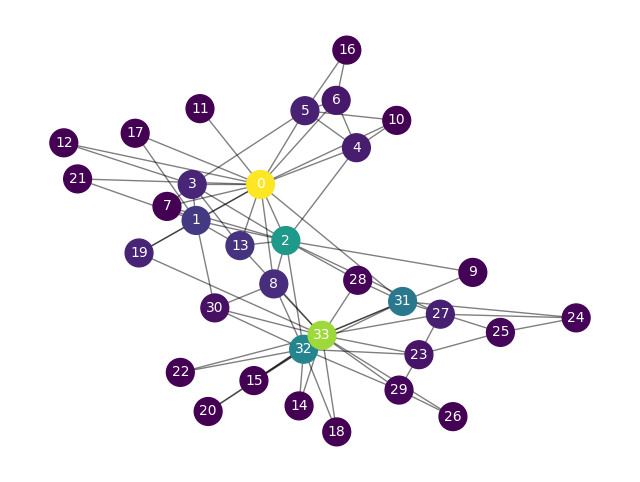

In [3]:
G = nx.karate_club_graph()
G.add_edges_from([(1,2),(2,3),(2,4),(3,5),(4,5)])

bc_ind = indicator_betweenness_unscaled(G, endpoints=False)
print(bc_ind)
node_values = [bc_ind[v] for v in G.nodes()]

# Draw
pos = nx.spring_layout(G, seed=42)  # layout for positioning

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_values,
    cmap=plt.cm.viridis,   # choose any matplotlib colormap
    node_size=400
)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")
plt.axis("off")
plt.show()

### P3 (b)

In [4]:
class CentralityError(Exception):
    """Custom exception for centrality computation errors."""

def _validate_graph(G, require_connected=False, messages=None):
    if messages is None:
        messages = []

    # ii) Not a networkx object
    if not isinstance(G, (nx.Graph, nx.DiGraph, nx.MultiGraph, nx.MultiDiGraph)):
        raise TypeError(
            "Expected a NetworkX graph (Graph/DiGraph/MultiGraph/MultiDiGraph), "
            f"got {type(G).__name__!r}."
        )

    n = G.number_of_nodes()
    m = G.number_of_edges()

    if n == 0:
        # iii) No connectivity / empty
        raise CentralityError("Empty graph: no nodes; betweenness centrality is undefined.")

    if n == 1:
        messages.append("Single-node graph: betweenness for the only node is 0 by definition.")

    if m == 0 and n > 1:
        # iii) No connectivity / edgeless
        messages.append(
            "Edgeless graph: no paths exist between distinct nodes; all betweenness scores are 0."
        )

    # Optional strict connectivity requirement
    if require_connected:
        if G.is_directed():
            if not nx.is_weakly_connected(G):
                raise CentralityError(
                    "Graph is not weakly connected: some node pairs are unreachable; "
                    "betweenness across those pairs is undefined under this setting."
                )
        else:
            if not nx.is_connected(G):
                raise CentralityError(
                    "Graph is not connected: some node pairs are unreachable; "
                    "betweenness across those pairs is undefined under this setting."
                )
    else:
        # Soft warning for common “not enough connectivity” cases
        if G.is_directed():
            if not nx.is_weakly_connected(G) and m > 0:
                messages.append(
                    "Warning: directed graph is not weakly connected; unreachable pairs will be ignored "
                    "(their contribution is 0) which can bias centrality toward nodes in larger/denser components."
                )
        else:
            if not nx.is_connected(G) and m > 0:
                messages.append(
                    "Warning: undirected graph is not connected; unreachable pairs will be ignored "
                    "(their contribution is 0) which can bias centrality toward nodes in larger/denser components."
                )

    return messages


def all_shortest_from(G, s):
    """
    Unweighted BFS from source s.
    Returns:
      dist[v] : shortest-path distance from s to v (=-1 if unreachable)
      g[v]    : number of shortest paths from s to v
      P[v]    : list of predecessors of v on shortest s->v paths
    """
    # iii-b) Node not present
    if s not in G:
        raise KeyError(f"Source node {s!r} is not in the graph.")

    dist = {v: -1 for v in G.nodes()}
    g    = {v:  0 for v in G.nodes()}
    P    = {v: [] for v in G.nodes()}

    dist[s] = 0
    g[s] = 1

    Q = deque([s])
    while Q:
        v = Q.popleft()
        # Use G.successors for DiGraph to respect direction; neighbors() works for undirected.
        nbr_iter = G.successors(v) if isinstance(G, (nx.DiGraph, nx.MultiDiGraph)) else G.neighbors(v)
        for w in nbr_iter:
            if dist[w] < 0:
                dist[w] = dist[v] + 1
                Q.append(w)
            if dist[w] == dist[v] + 1:
                g[w] += g[v]
                P[w].append(v)
    return dist, g, P


def indicator_betweenness_unscaled(
    G,
    endpoints=False,
    *,
    return_messages=False,
    require_connected=False
):
    """
    Indicator betweenness (UNWEIGHTED, UNSCALED):
      For each ordered pair (s, t), s!=t, every node i on at least one
      shortest s->t path gets + 1 / g_st (once per pair).

    endpoints=False: do NOT credit s or t.
    endpoints=True : DO credit s and t as well.

    Parameters
    ----------
    G : networkx graph
    endpoints : bool
    return_messages : bool
        If True, returns (bc_dict, messages_list). Otherwise returns bc_dict only.
    require_connected : bool
        If True, raises on disconnected graphs (see _validate_graph).
    """
    messages = _validate_graph(G, require_connected=require_connected, messages=[])

    # iii) Trivial cases handled up-front to avoid unnecessary work
    n = G.number_of_nodes()
    m = G.number_of_edges()
    if n == 1:
        only = next(iter(G.nodes()))
        result = {only: 0.0}
        return (result, messages) if return_messages else result
    if m == 0:
        result = {v: 0.0 for v in G.nodes()}
        return (result, messages) if return_messages else result

    bc = {v: 0.0 for v in G.nodes()}
    nodes = list(G.nodes())

    # iv) Numerical safety: everything below ensures we never divide by zero.
    #     We also check for path count overflow, though in Python ints are unbounded.
    skipped_zero_path_pairs = 0

    for s in nodes:
        # all_shortest_from already checks "node not in graph"
        dist, g, P = all_shortest_from(G, s)

        # Reachable targets t != s with at least one shortest path
        targets = [t for t in nodes if t != s and g[t] > 0]

        # Count unreachable targets for diagnostics
        skipped_zero_path_pairs += sum(1 for t in nodes if t != s and g[t] == 0)

        for t in targets:
            # iv) Guard divide-by-zero (shouldn’t trigger due to filter, but keep it bulletproof)
            paths_st = g[t]
            if paths_st == 0:
                continue  # unreachable; contributes nothing

            contrib = 1.0 / paths_st

            # Reverse-walk the predecessor DAG from t to mark all nodes on
            # at least one shortest s->t path.
            stack = [t]
            visited = {t}
            while stack:
                w = stack.pop()

                # Credit rule: indicator version
                if endpoints:
                    bc[w] += contrib
                else:
                    if w != s and w != t:
                        bc[w] += contrib

                for v in P[w]:
                    if v not in visited:
                        visited.add(v)
                        stack.append(v)

    if skipped_zero_path_pairs > 0:
        messages.append(
            f"Info: {skipped_zero_path_pairs} ordered (s,t) pairs were unreachable; "
            "they contribute 0 by definition."
        )

    return (bc, messages) if return_messages else bc


In [5]:
# 1) Sanity check with a tiny connected graph
G = nx.path_graph(4)  # 0-1-2-3

bc, msgs = indicator_betweenness_unscaled(G, return_messages=True)
print("BC:", bc)
print("Messages:", msgs)

# 2) Edgeless graph -> zeros + message
H = nx.empty_graph(3)
bc2, msgs2 = indicator_betweenness_unscaled(H, return_messages=True)
print("BC (edgeless):", bc2)
print("Messages (edgeless):", msgs2)

# 3) Disconnected graph -> works, plus warning message
I = nx.Graph()
I.add_edges_from([(1,2), (3,4)])  # 2 components
bc3, msgs3 = indicator_betweenness_unscaled(I, return_messages=True)
print("BC (disconnected):", bc3)
print("Messages (disconnected):", msgs3)


BC: {0: 0.0, 1: 4.0, 2: 4.0, 3: 0.0}
Messages: []
BC (edgeless): {0: 0.0, 1: 0.0, 2: 0.0}
Messages (edgeless): ['Edgeless graph: no paths exist between distinct nodes; all betweenness scores are 0.']
BC (disconnected): {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}
Messages (disconnected): ['Warning: undirected graph is not connected; unreachable pairs will be ignored (their contribution is 0) which can bias centrality toward nodes in larger/denser components.', 'Info: 8 ordered (s,t) pairs were unreachable; they contribute 0 by definition.']


### P3 (c)

In [6]:
def nx_bc(G, endpoints=False):
    # Use normalized=False to match "unscaled" convention
    return nx.betweenness_centrality(G, normalized=False, endpoints=endpoints)

def diff(bc1, bc2, tol=1e-12):
    keys = sorted(set(bc1) | set(bc2))
    return {k: bc1.get(k, 0.0) - bc2.get(k, 0.0) for k in keys if abs(bc1.get(k,0.0)-bc2.get(k,0.0)) > tol}

# 1) Unique-shortest-path graphs -> MATCH
# (a) Path graph (tree)
G1 = nx.path_graph(5)  # 0-1-2-3-4
my1  = indicator_betweenness_unscaled(G1, endpoints=False)
nx1  = nx_bc(G1, endpoints=False)
print("Path graph diffs:", diff(my1, nx1))  # expect {}

# (b) Directed acyclic with unique paths
G2 = nx.DiGraph()
G2.add_edges_from([(0,1),(1,2),(2,3),(1,3)])
my2  = indicator_betweenness_unscaled(G2, endpoints=False)
nx2  = nx_bc(G2, endpoints=False)
print("DAG diffs:", diff(my2, nx2))  # expect {}

# 2) Multiple *disjoint* shortest paths where a node lies on only one of them -> STILL MATCH
#    Cycle C4: opposite corners have two shortest paths, each middle node on exactly one.
G3 = nx.cycle_graph(4)  # 0-1-2-3-0
my3  = indicator_betweenness_unscaled(G3, endpoints=False)
nx3  = nx_bc(G3, endpoints=False)
print("C4 diffs:", diff(my3, nx3))  # expect {}

# 3) Multiple shortest paths that BOTH pass through the SAME node -> DIFFER
#    "Diamond-with-merging" shape: s--x--v--t and s--y--v--t are both shortest; both include v.
#    Undirected version:
G4 = nx.Graph()
s, x, y, v, t = 0, 1, 2, 3, 4
G4.add_edges_from([(s,x),(s,y),(x,v),(y,v),(v,t)])
my4  = indicator_betweenness_unscaled(G4, endpoints=False)
nx4  = nx_bc(G4, endpoints=False)
print("Diamond diffs:", diff(my4, nx4))  # expect nonempty, v will be lower in metric

# 4) Disconnected graph -> both effectively ignore unreachable pairs, results often 0s
G5 = nx.Graph()
G5.add_edges_from([(1,2), (3,4)])  # two components
my5, msg5 = indicator_betweenness_unscaled(G5, endpoints=False, return_messages=True)
nx5 = nx_bc(G5, endpoints=False)
print("Disconnected diffs:", diff(my5, nx5))  # usually {}
print("Messages:", msg5)



Path graph diffs: {1: 3.0, 2: 4.0, 3: 3.0}
DAG diffs: {}
C4 diffs: {0: 0.5, 1: 0.5, 2: 0.5, 3: 0.5}
Diamond diffs: {0: 0.5, 1: 1.0, 2: 1.0, 3: 2.5}
Disconnected diffs: {}
Messages: ['Warning: undirected graph is not connected; unreachable pairs will be ignored (their contribution is 0) which can bias centrality toward nodes in larger/denser components.', 'Info: 8 ordered (s,t) pairs were unreachable; they contribute 0 by definition.']


### P4 (d)

In [7]:
import math
def _almost_equal(a, b, tol=1e-9):
    return abs(a - b) <= tol

def _all_zeros(d, tol=1e-12):
    return all(abs(v) <= tol for v in d.values())

def _uniform_values(d, tol=1e-12):
    vals = list(d.values())
    return max(vals) - min(vals) <= tol

def test_centrality(
    cfunc,
    *,
    endpoints=False,
    require_connected=False,
    name=None,
    tol=1e-9,
    extra_kwargs=None
):
    """
    Run robustness + correctness tests on a centrality function.

    Parameters
    ----------
    cfunc : callable
        A function like cfunc(G, **kwargs) -> dict[node->float]
        (e.g., your `indicator_betweenness_unscaled`).
    endpoints : bool
        Passed through to cfunc if supported.
    require_connected : bool
        Passed through to cfunc if supported.
    name : str | None
        Name shown in the report.
    tol : float
        Numeric tolerance for equality checks.
    extra_kwargs : dict | None
        Any additional kwargs to forward to cfunc.

    Returns
    -------
    report : dict
        {test_name: {"ok": bool, "detail": str}}
    """
    if extra_kwargs is None:
        extra_kwargs = {}

    # Helper: call centrality with flexible kwargs (ignore unsupported)
    def _call(G):
        kw = {}
        for k, v in dict(endpoints=endpoints, require_connected=require_connected, **extra_kwargs).items():
            # Try passing; if TypeError (unknown kw), call again without that kw
            try:
                return cfunc(G, **{**kw, k: v})
            except TypeError as e:
                # Unknown kw; skip it and continue collecting others
                continue
        # Try once more with whatever kws survived (may be empty)
        return cfunc(G, **kw)

    report = {}
    algo_name = name or getattr(cfunc, "__name__", "centrality_func")

    # =============== ROBUSTNESS / EDGE CASES =================

    # 0) Non-graph input
    try:
        try:
            _ = _call("not a graph")
            report["non_graph_input"] = {"ok": False, "detail": "Expected TypeError or similar, got no error."}
        except Exception as e:
            report["non_graph_input"] = {"ok": True, "detail": f"Raised as expected: {type(e).__name__}: {e}"}
    except Exception as e:
        report["non_graph_input"] = {"ok": False, "detail": f"Unexpected wrapper error: {e}"}

    # 1) Empty graph
    G = nx.Graph()
    try:
        _ = _call(G)
        report["empty_graph"] = {"ok": False, "detail": "Expected an error for empty graph, got result."}
    except Exception as e:
        report["empty_graph"] = {"ok": True, "detail": f"Raised as expected: {type(e).__name__}: {e}"}

    # 2) Single node
    G = nx.Graph()
    G.add_node(0)
    try:
        res = _call(G)
        ok = _almost_equal(res.get(0, None), 0.0, tol)
        report["single_node"] = {"ok": ok, "detail": f"value={res.get(0)} expected 0.0"}
    except Exception as e:
        report["single_node"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # 3) Edgeless graph (n>1)
    G = nx.empty_graph(5)  # 5 isolated nodes
    try:
        res = _call(G)
        ok = _all_zeros(res, tol)
        report["edgeless_graph"] = {"ok": ok, "detail": f"values={res}"}
    except Exception as e:
        report["edgeless_graph"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # 4) Disconnected (two components)
    G = nx.Graph()
    G.add_edges_from([(0,1),(1,2)])  # comp A
    G.add_edges_from([(10,11)])      # comp B
    try:
        res = _call(G)
        ok = all(val >= -tol for val in res.values())  # just ensure it runs and is finite
        # In indicator betweenness, unreachable pairs contribute 0 → scores depend only on intra-component pairs.
        report["disconnected_graph"] = {"ok": ok, "detail": f"values={res}"}
    except Exception as e:
        report["disconnected_graph"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # 5) Directed not weakly connected
    DG = nx.DiGraph()
    DG.add_edges_from([(0,1),(1,2)])        # comp A (reachable chain)
    DG.add_edges_from([(10,11)])            # comp B
    try:
        res = _call(DG)
        ok = all(math.isfinite(v) for v in res.values())
        report["directed_not_weakly_connected"] = {"ok": ok, "detail": f"values={res}"}
    except Exception as e:
        report["directed_not_weakly_connected"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # =============== CORRECTNESS / KNOWN CASES =================

    # A) Triangle K3 → no interior nodes, all zeros
    G = nx.cycle_graph(3)
    try:
        res = _call(G)
        ok = _all_zeros(res, tol)
        report["K3_triangle_all_zero"] = {"ok": ok, "detail": f"values={res}"}
    except Exception as e:
        report["K3_triangle_all_zero"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # B) Path P5: 0-1-2-3-4
    # Indicator & standard (unweighted, unscaled) coincide here (unique shortest paths)
    G = nx.path_graph(5)
    try:
        res = _call(G)
        exp = {0:0.0, 1:6.0, 2:8.0, 3:6.0, 4:0.0}  # ordered pairs counting
        ok = all(_almost_equal(res.get(k, None), v, tol) for k,v in exp.items())
        report["path_P5_exact_counts"] = {"ok": ok, "detail": f"got={res}, expected={exp}"}
    except Exception as e:
        report["path_P5_exact_counts"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # C) Star S5: center 0, leaves 1..4 → center gets all leaf-leaf pairs, leaves 0
    G = nx.Graph()
    G.add_node(0)
    for i in range(1,5):
        G.add_edge(0, i)
    try:
        res = _call(G)
        # ordered leaf-leaf pairs: 4*3 = 12 pass through center; leaves get 0
        ok = _almost_equal(res.get(0, None), 12.0, tol) and all(_almost_equal(res.get(i, None), 0.0, tol) for i in range(1,5))
        report["star_S5_center_12_leaves_0"] = {"ok": ok, "detail": f"values={res} (expect center=12, others 0)"}
    except Exception as e:
        report["star_S5_center_12_leaves_0"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # D) Cycle C4 (0-1-2-3-0): symmetry → all nodes equal (indicator version)
    G = nx.cycle_graph(4)
    try:
        res = _call(G)
        ok = _uniform_values(res, tol)
        report["cycle_C4_uniform"] = {"ok": ok, "detail": f"values={res} (expect all equal by symmetry)"}
    except Exception as e:
        report["cycle_C4_uniform"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # E) Directed chain 0->1->2->3:
    # Ordered pairs only along direction:
    #  - node 1 lies on paths (0->2, 0->3) => 2
    #  - node 2 lies on paths (0->3, 1->3) => 2
    #  - endpoints 0,3 get 0 (endpoints=False)
    DG = nx.DiGraph()
    DG.add_edges_from([(0,1),(1,2),(2,3)])
    try:
        res = _call(DG)
        exp = {0:0.0, 1:2.0, 2:2.0, 3:0.0}
        ok = all(_almost_equal(res.get(k, None), v, tol) for k,v in exp.items())
        report["directed_chain_exact"] = {"ok": ok, "detail": f"got={res}, expected={exp}"}
    except Exception as e:
        report["directed_chain_exact"] = {"ok": False, "detail": f"Raised unexpectedly: {type(e).__name__}: {e}"}

    # Done
    header = f"Centrality test report for: {algo_name}"
    return {"name": algo_name, "report": report, "summary_ok": all(x["ok"] for x in report.values()), "note": header}


In [8]:
# Assuming your indicator function is defined:
# indicator_betweenness_unscaled(G, endpoints=False, return_messages=False, require_connected=False)

r = test_centrality(
    indicator_betweenness_unscaled,
    endpoints=False,           # forwarded if supported
    require_connected=False,   # forwarded if supported
    name="indicator_betweenness_unscaled",
    tol=1e-9
)

# Pretty print
print(r["note"])
for k, v in r["report"].items():
    print(f"{k:28s}  ->  {'OK' if v['ok'] else 'FAIL'} | {v['detail']}")
print("OVERALL:", "PASS" if r["summary_ok"] else "FAIL")


Centrality test report for: indicator_betweenness_unscaled
non_graph_input               ->  OK | Raised as expected: TypeError: Expected a NetworkX graph (Graph/DiGraph/MultiGraph/MultiDiGraph), got 'str'.
empty_graph                   ->  OK | Raised as expected: CentralityError: Empty graph: no nodes; betweenness centrality is undefined.
single_node                   ->  OK | value=0.0 expected 0.0
edgeless_graph                ->  OK | values={0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}
disconnected_graph            ->  OK | values={0: 0.0, 1: 2.0, 2: 0.0, 10: 0.0, 11: 0.0}
directed_not_weakly_connected  ->  OK | values={0: 0.0, 1: 1.0, 2: 0.0, 10: 0.0, 11: 0.0}
K3_triangle_all_zero          ->  OK | values={0: 0.0, 1: 0.0, 2: 0.0}
path_P5_exact_counts          ->  OK | got={0: 0.0, 1: 6.0, 2: 8.0, 3: 6.0, 4: 0.0}, expected={0: 0.0, 1: 6.0, 2: 8.0, 3: 6.0, 4: 0.0}
star_S5_center_12_leaves_0    ->  OK | values={0: 12.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0} (expect center=12, others 0)
cycle_